In [1]:
import os
import pandas as pd 
import random
from manga109api import Parser

"That'sIzumiko"

"UchiNoNyan'sDiary"

These contain apostrophes ', which break zip packaging or Kaggle uploads.

In [2]:
rename_map = {
    "That'sIzumiko": "ThatsIzumiko",
    "UchiNoNyan'sDiary": "UchiNoNyansDiary"
}

In [3]:
random.seed(42)

In [4]:
ROOT_DIR = "./Dataset/Manga109s"
OUTPUT_DIR = './Dataset/Manga109s'

In [5]:
# ─── Parse annotations ───
parser = Parser(root_dir=ROOT_DIR)
titles = parser.books
random.seed(42)
random.shuffle(titles)

In [6]:
titles.count("That'sIzumiko")

1

In [7]:
# SPLIT TITLES
n = len(titles)
train_titles = titles[:int(n * 0.8)]
val_titles = titles[int(n * 0.8):int(n * 0.9)]
test_titles = titles[int(n * 0.9):]

In [8]:
def create_split_df(title_list, split_name):
    rows = []
    for title in title_list:
            safe_title = rename_map.get(title, title) 
            ann = parser.get_annotation(title)
            for page in ann["page"]:
                    idx = int(page["@index"])
                    img_name = f"{int(idx):03d}.jpg"
                    rows.append({
                        "image_path": f"images/{safe_title}/{img_name}",
                        "title": safe_title,
                        "page_index": idx,
                        "annotation_path": f"annotations/{safe_title}.xml"
                })
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUTPUT_DIR, f"{split_name}.csv"), index=False)
    print(f"{split_name}.csv: {len(df)} entries")


In [11]:
create_split_df(train_titles,'train')

train.csv: 6788 entries


In [12]:
create_split_df(val_titles, "val")
create_split_df(test_titles, "test")

val.csv: 824 entries
test.csv: 907 entries


In [13]:
df = pd.read_csv('./Dataset/Manga109s/train.csv')

In [14]:
df.head()

,image_path,title,page_index,annotation_path
0,images/EvaLady/000.jpg,EvaLady,0,annotations/EvaLady.xml
1,images/EvaLady/001.jpg,EvaLady,1,annotations/EvaLady.xml
2,images/EvaLady/002.jpg,EvaLady,2,annotations/EvaLady.xml
3,images/EvaLady/003.jpg,EvaLady,3,annotations/EvaLady.xml
4,images/EvaLady/004.jpg,EvaLady,4,annotations/EvaLady.xml


In [18]:
df[df['title'] == 'UchiNoNyansDiary']

,image_path,title,page_index,annotation_path
4856,images/UchiNoNyansDiary/000.jpg,UchiNoNyansDiary,0,annotations/UchiNoNyansDiary.xml
4857,images/UchiNoNyansDiary/001.jpg,UchiNoNyansDiary,1,annotations/UchiNoNyansDiary.xml
4858,images/UchiNoNyansDiary/002.jpg,UchiNoNyansDiary,2,annotations/UchiNoNyansDiary.xml
4859,images/UchiNoNyansDiary/003.jpg,UchiNoNyansDiary,3,annotations/UchiNoNyansDiary.xml
4860,images/UchiNoNyansDiary/004.jpg,UchiNoNyansDiary,4,annotations/UchiNoNyansDiary.xml
...,...,...,...,...
4933,images/UchiNoNyansDiary/077.jpg,UchiNoNyansDiary,77,annotations/UchiNoNyansDiary.xml
4934,images/UchiNoNyansDiary/078.jpg,UchiNoNyansDiary,78,annotations/UchiNoNyansDiary.xml
4935,images/UchiNoNyansDiary/079.jpg,UchiNoNyansDiary,79,annotations/UchiNoNyansDiary.xml
4936,images/UchiNoNyansDiary/080.jpg,UchiNoNyansDiary,80,annotations/UchiNoNyansDiary.xml


In [20]:
df[df['title']=='ThatsIzumiko']

,image_path,title,page_index,annotation_path
1988,images/ThatsIzumiko/000.jpg,ThatsIzumiko,0,annotations/ThatsIzumiko.xml
1989,images/ThatsIzumiko/001.jpg,ThatsIzumiko,1,annotations/ThatsIzumiko.xml
1990,images/ThatsIzumiko/002.jpg,ThatsIzumiko,2,annotations/ThatsIzumiko.xml
1991,images/ThatsIzumiko/003.jpg,ThatsIzumiko,3,annotations/ThatsIzumiko.xml
1992,images/ThatsIzumiko/004.jpg,ThatsIzumiko,4,annotations/ThatsIzumiko.xml
...,...,...,...,...
2110,images/ThatsIzumiko/122.jpg,ThatsIzumiko,122,annotations/ThatsIzumiko.xml
2111,images/ThatsIzumiko/123.jpg,ThatsIzumiko,123,annotations/ThatsIzumiko.xml
2112,images/ThatsIzumiko/124.jpg,ThatsIzumiko,124,annotations/ThatsIzumiko.xml
2113,images/ThatsIzumiko/125.jpg,ThatsIzumiko,125,annotations/ThatsIzumiko.xml


In [26]:
# # Rename image folders
# for old, new in rename_map.items():
#     os.rename(f"./Dataset/Manga109s/images/{old}", f"./Dataset/Manga109s/images/{new}")

# Rename XML files
for old, new in rename_map.items():
    os.rename(f"./Dataset/Manga109s/annotations/{old}.xml", f"./Dataset/Manga109s/annotations/{new}.xml")

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

Image path: Dataset\Manga109s\images\EvaLady\010.jpg


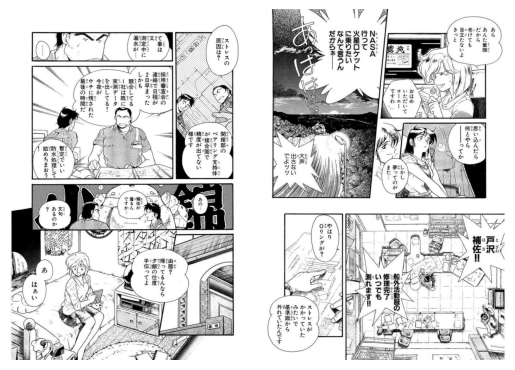

In [25]:
img_path = os.path.normpath(os.path.join(OUTPUT_DIR, df.loc[10, 'image_path']))
print("Image path:", img_path)  # Debug print

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()